# Task 1 — Improved NASDAQ LSTM Model

Experiments with four improvements over the original Task 1 baseline:

| # | Improvement | Rationale |
|---|-------------|-----------|
| 1 | **Ridge linear baseline** | Diagnose whether features or architecture is the bottleneck |
| 2 | **Simplified LSTM** (32 units) | Original 128→64→32 overfits; val MAE flat from epoch 1 |
| 3 | **LSTM + Temporal Attention** | Focus on the most informative days in the window |
| 4 | **Cross-sectional + regime features** | Alpha vs SPY, market volatility — signal the original 20 features can't provide |

Everything else (log-return target, StandardScaler on train only, chronological split, Huber loss) is identical to the original.

In [24]:
import os, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error

import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Input, LSTM, Dense, Dropout, LayerNormalization,
    MultiHeadAttention, GlobalAveragePooling1D, Add,
)
from tensorflow.keras.regularizers import l2
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

warnings.filterwarnings('ignore')
np.random.seed(42)
tf.random.set_seed(42)

print('TensorFlow :', tf.__version__)
print('NumPy      :', np.__version__)
print('Pandas     :', pd.__version__)

TensorFlow : 2.21.0
NumPy      : 2.4.3
Pandas     : 3.0.1


## 1. Configuration

In [25]:
NASDAQ_DATA_DIR = 'nasdaq-historical-data/'
LOOKBACK    = 30        # 30-day window — plenty of signal without too much padding
TRAIN_RATIO = 0.70
VAL_RATIO   = 0.15
YF_YEARS    = 10        # fetch 10 years from yfinance (≈2500 trading days)

DEMO_TICKER = 'AAPL'   # swap to any NASDAQ ticker

print('Lookback window :', LOOKBACK, 'trading days')
print('History         :', YF_YEARS, 'years from yfinance')
print('Train/Val/Test  : 70/15/15')


Lookback window : 30 trading days
History         : 10 years from yfinance
Train/Val/Test  : 70/15/15


## 2. Data Loading

In [26]:
import datetime

def fetch_ticker_yf(ticker, years=YF_YEARS):
    """Download OHLCV from yfinance; falls back to local CSV if unavailable."""
    end   = datetime.date.today()
    start = end - datetime.timedelta(days=years * 365 + 10)
    raw   = yf.Ticker(ticker).history(start=str(start), end=str(end), interval='1d', auto_adjust=True)
    if raw.empty:
        print('yfinance empty for ' + ticker + ' — falling back to CSV')
        return load_ticker_csv_fallback(ticker)
    raw.index = pd.to_datetime(raw.index).tz_localize(None)
    df = raw[['Open', 'High', 'Low', 'Close', 'Volume']].copy()
    df.index.name = 'Date'
    df = df.reset_index()
    for col in ['Open', 'High', 'Low', 'Close', 'Volume']:
        df[col] = pd.to_numeric(df[col], errors='coerce')
    df = df.dropna(subset=['Close']).reset_index(drop=True)
    d0 = df['Date'].iloc[0].date()
    d1 = df['Date'].iloc[-1].date()
    print('Fetched ' + ticker + ': ' + str(len(df)) + ' rows  [' + str(d0) + ' -> ' + str(d1) + ']')
    return df


def load_ticker_csv_fallback(ticker, data_dir=NASDAQ_DATA_DIR):
    path = os.path.join(data_dir, ticker + '_Historical.csv')
    df = pd.read_csv(path)
    df.columns = df.columns.str.strip()
    df['Date'] = pd.to_datetime(df['Date'])
    df = df.sort_values('Date').reset_index(drop=True)
    for col in ['Open', 'High', 'Low', 'Close', 'Volume']:
        df[col] = pd.to_numeric(df[col], errors='coerce')
    df = df.dropna(subset=['Close']).reset_index(drop=True)
    d0 = df['Date'].iloc[0].date()
    d1 = df['Date'].iloc[-1].date()
    print('Loaded CSV ' + ticker + ': ' + str(len(df)) + ' rows  [' + str(d0) + ' -> ' + str(d1) + ']')
    return df


def fetch_spy(start, end):
    raw = yf.Ticker('SPY').history(start=start, end=end, interval='1d', auto_adjust=True)
    if raw.empty:
        print('WARNING: SPY unavailable — cross-sectional features will be zeroed')
        return None
    raw.index = pd.to_datetime(raw.index).tz_localize(None)
    spy = raw['Close'].rename('SPY')
    print('SPY fetched:', len(spy), 'rows  [' + str(spy.index[0].date()) + ' -> ' + str(spy.index[-1].date()) + ']')
    return spy


df_demo = fetch_ticker_yf(DEMO_TICKER)
spy_prices = fetch_spy(
    start=str(df_demo['Date'].iloc[0].date()),
    end=str((df_demo['Date'].iloc[-1] + pd.Timedelta(days=2)).date()),
)


Fetched AAPL: 2519 rows  [2016-04-13 -> 2026-04-20]
SPY fetched: 2519 rows  [2016-04-13 -> 2026-04-20]


## 3. Feature Engineering

Adds 6 cross-sectional features on top of the original 20:

**Alpha features** (stock excess return vs SPY):
- `alpha_1d`, `alpha_5d`, `alpha_20d`

**Regime features** (what kind of market today):
- `market_trend_20d` — SPY 20-day return (positive = bull)
- `market_vol_20d` — SPY rolling volatility (high = risk-off)
- `rel_volume_alpha` — stock volume anomaly vs its own 20-day average

In [27]:
def add_original_features(df):
    """Exact 20 features from the original notebook."""
    df = df.copy().reset_index(drop=True)
    close  = df['Close']
    high   = df['High']
    low    = df['Low']
    volume = df['Volume']
    c_safe = close.replace(0, float('nan'))

    sma10 = close.rolling(10).mean()
    sma20 = close.rolling(20).mean()
    sma50 = close.rolling(50).mean()
    ema10 = close.ewm(span=10, adjust=False).mean()
    ema20 = close.ewm(span=20, adjust=False).mean()

    df['SMA10_vs_SMA20'] = sma10 / sma20.replace(0, float('nan')) - 1
    df['SMA20_vs_SMA50'] = sma20 / sma50.replace(0, float('nan')) - 1
    df['EMA10_vs_EMA20'] = ema10 / ema20.replace(0, float('nan')) - 1
    df['Close_vs_SMA20'] = close / sma20.replace(0, float('nan')) - 1
    df['Close_vs_SMA50'] = close / sma50.replace(0, float('nan')) - 1

    delta = close.diff()
    gain  = delta.clip(lower=0).rolling(14).mean()
    loss  = (-delta).clip(lower=0).rolling(14).mean()
    rs    = gain / loss.replace(0, float('nan'))
    df['RSI_14'] = 100 - (100 / (1 + rs))

    ema12       = close.ewm(span=12, adjust=False).mean()
    ema26       = close.ewm(span=26, adjust=False).mean()
    macd_line   = ema12 - ema26
    macd_signal = macd_line.ewm(span=9, adjust=False).mean()
    df['MACD_pct']      = macd_line   / c_safe
    df['MACD_sig_pct']  = macd_signal / c_safe
    df['MACD_hist_pct'] = (macd_line - macd_signal) / c_safe

    bb_mid = close.rolling(20).mean()
    bb_std = close.rolling(20).std()
    bb_range = (4 * bb_std).replace(0, float('nan'))
    df['BB_width'] = (4 * bb_std) / bb_mid.replace(0, float('nan'))
    df['BB_pct']   = (close - (bb_mid - 2 * bb_std)) / bb_range

    tr = pd.concat([
        high - low,
        (high - close.shift(1)).abs(),
        (low  - close.shift(1)).abs(),
    ], axis=1).max(axis=1)
    df['ATR_pct'] = tr.rolling(14).mean() / c_safe

    log_ret = np.log(close / close.shift(1))
    df['Volatility_10'] = log_ret.rolling(10).std()
    df['Volatility_20'] = log_ret.rolling(20).std()
    df['Return_1d']     = log_ret
    df['Return_5d']     = np.log(close / close.shift(5))
    df['Return_10d']    = np.log(close / close.shift(10))
    df['Return_20d']    = np.log(close / close.shift(20))

    vol_ma20 = volume.rolling(20).mean().replace(0, float('nan'))
    df['Volume_ratio'] = volume / vol_ma20
    df['High_Low_pct'] = (high - low) / c_safe

    return df


def add_cross_features(df, spy):
    """Add alpha vs SPY and regime features. Defaults to 0 if SPY unavailable."""
    df = df.copy()
    close = df['Close']

    if spy is not None:
        spy_al = spy.reindex(df['Date'].values, method='ffill').values
        spy_s  = pd.Series(spy_al, index=df.index)

        spy_r1  = np.log(spy_s / spy_s.shift(1))
        spy_r5  = np.log(spy_s / spy_s.shift(5))
        spy_r20 = np.log(spy_s / spy_s.shift(20))

        df['alpha_1d']         = np.log(close / close.shift(1))  - spy_r1
        df['alpha_5d']         = np.log(close / close.shift(5))  - spy_r5
        df['alpha_20d']        = np.log(close / close.shift(20)) - spy_r20
        df['market_trend_20d'] = spy_r20
        df['market_vol_20d']   = spy_r1.rolling(20).std()
        df['rel_volume_alpha'] = df['Volume_ratio'] - df['Volume_ratio'].rolling(20).mean()
    else:
        for col in ['alpha_1d', 'alpha_5d', 'alpha_20d',
                    'market_trend_20d', 'market_vol_20d', 'rel_volume_alpha']:
            df[col] = 0.0
    return df


ORIGINAL_FEATURES = [
    'Return_1d', 'Return_5d', 'Return_10d', 'Return_20d',
    'SMA10_vs_SMA20', 'SMA20_vs_SMA50', 'EMA10_vs_EMA20',
    'Close_vs_SMA20', 'Close_vs_SMA50',
    'RSI_14', 'MACD_pct', 'MACD_sig_pct', 'MACD_hist_pct',
    'BB_width', 'BB_pct', 'ATR_pct',
    'Volatility_10', 'Volatility_20', 'Volume_ratio', 'High_Low_pct',
]
CROSS_FEATURES = [
    'alpha_1d', 'alpha_5d', 'alpha_20d',
    'market_trend_20d', 'market_vol_20d', 'rel_volume_alpha',
]
FEATURE_COLS = ORIGINAL_FEATURES + CROSS_FEATURES
N_FEATURES   = len(FEATURE_COLS)
print('Total features:', N_FEATURES, '(', len(ORIGINAL_FEATURES), 'original +', len(CROSS_FEATURES), 'cross-sectional )')

Total features: 26 ( 20 original + 6 cross-sectional )


## 4. Preprocessing (identical pipeline to original)

In [28]:
def preprocess_ticker(df, spy, lookback=LOOKBACK):
    df_feat = add_original_features(df)
    df_feat = add_cross_features(df_feat, spy)

    close      = df_feat['Close']
    log_return = np.log(close.shift(-1) / close)
    df_feat['_target'] = log_return

    df_feat = df_feat.dropna(subset=FEATURE_COLS + ['_target', 'Close']).reset_index(drop=True)

    X_raw    = df_feat[FEATURE_COLS].values.astype('float32')
    y_logret = df_feat['_target'].values.astype('float32')
    y_close  = df_feat['Close'].values.astype('float32')
    dates    = df_feat['Date'].values

    n       = len(X_raw) - lookback
    n_train = int(n * TRAIN_RATIO)
    n_val   = int(n * VAL_RATIO)
    n_test  = n - n_train - n_val

    train_row_end = n_train + lookback - 1
    scaler_X = StandardScaler().fit(X_raw[:train_row_end])
    scaler_y = StandardScaler().fit(y_logret[:n_train + lookback].reshape(-1, 1))

    X_sc = scaler_X.transform(X_raw)
    y_sc = scaler_y.transform(y_logret.reshape(-1, 1)).flatten()

    X_seq, y_seq, close_seq, date_seq = [], [], [], []
    for i in range(n):
        X_seq.append(X_sc[i : i + lookback])
        y_seq.append(y_sc[i + lookback])
        close_seq.append(y_close[i + lookback - 1])
        date_seq.append(dates[i + lookback])

    X_seq = np.array(X_seq, dtype='float32')
    y_seq = np.array(y_seq, dtype='float32')
    close_seq = np.array(close_seq, dtype='float32')
    date_seq  = np.array(date_seq)

    slices = {
        'train': slice(0,               n_train),
        'val'  : slice(n_train,         n_train + n_val),
        'test' : slice(n_train + n_val, n),
    }
    data = {'scaler_X': scaler_X, 'scaler_y': scaler_y,
            'n_train': n_train, 'n_val': n_val, 'n_test': n_test}
    for split, sl in slices.items():
        data['X_' + split]     = X_seq[sl]
        data['y_' + split]     = y_seq[sl]
        data['close_' + split] = close_seq[sl]
        data['dates_' + split] = date_seq[sl]

    # Leakage audit
    t_end = pd.Timestamp(data['dates_train'][-1]).date()
    v_st  = pd.Timestamp(data['dates_val'][0]).date()
    te_st = pd.Timestamp(data['dates_test'][0]).date()
    assert t_end < v_st,  'LEAKAGE: train/val overlap!'
    assert v_st  < te_st, 'LEAKAGE: val/test overlap!'

    print('  train:', n_train, 'samples  [' + str(pd.Timestamp(data['dates_train'][0]).date()) + ' -> ' + str(t_end) + ']')
    print('  val  :', n_val,   'samples  [' + str(v_st) + ' -> ' + str(pd.Timestamp(data['dates_val'][-1]).date()) + ']')
    print('  test :', n_test,  'samples  [' + str(te_st) + ' -> ' + str(pd.Timestamp(data['dates_test'][-1]).date()) + ']')
    print('  Leakage audit passed')
    return data


print('Preprocessing', DEMO_TICKER, '...')
data = preprocess_ticker(df_demo, spy_prices)
print('X_train shape:', data['X_train'].shape)

Preprocessing AAPL ...
  train: 1707 samples  [2016-08-04 -> 2023-05-16]
  val  : 365 samples  [2023-05-17 -> 2024-10-28]
  test : 367 samples  [2024-10-29 -> 2026-04-17]
  Leakage audit passed
X_train shape: (1707, 30, 26)


## 5. Shared Metrics

In [29]:
def direction_accuracy(y_true_sc, y_pred_sc, close_today, scaler_y):
    """Directional accuracy (identical to original notebook)."""
    y_true = scaler_y.inverse_transform(y_true_sc.reshape(-1, 1)).flatten()
    y_pred = scaler_y.inverse_transform(y_pred_sc.reshape(-1, 1)).flatten()
    p_true = close_today * np.exp(y_true)
    p_pred = close_today * np.exp(y_pred)
    actual_dir = np.sign(p_true - close_today)
    pred_dir   = np.sign(p_pred - close_today)
    mask = actual_dir != 0
    return float(np.mean(actual_dir[mask] == pred_dir[mask])) * 100

## 6. Improvement 1 — Ridge Linear Baseline

**Diagnostic purpose:** If Ridge directional accuracy ≈ LSTM, the bottleneck is features, not the model architecture.

In [30]:
X_train_flat = data['X_train'].reshape(len(data['X_train']), -1)
X_val_flat   = data['X_val'].reshape(len(data['X_val']),   -1)
X_test_flat  = data['X_test'].reshape(len(data['X_test']), -1)

ridge = Ridge(alpha=1.0)
ridge.fit(X_train_flat, data['y_train'])

ridge_val_pred  = ridge.predict(X_val_flat)
ridge_test_pred = ridge.predict(X_test_flat)

ridge_val_dir  = direction_accuracy(data['y_val'],  ridge_val_pred,  data['close_val'],  data['scaler_y'])
ridge_test_dir = direction_accuracy(data['y_test'], ridge_test_pred, data['close_test'], data['scaler_y'])

print('Ridge Linear Baseline')
print('  Val  directional accuracy:', round(ridge_val_dir, 1), '%')
print('  Test directional accuracy:', round(ridge_test_dir, 1), '%')
print()
print('~50%  -> features contain no exploitable linear signal')
print('>52%  -> features have signal; LSTM should do more')
print('~LSTM -> bottleneck is features, not architecture')

Ridge Linear Baseline
  Val  directional accuracy: 51.2 %
  Test directional accuracy: 51.9 %

~50%  -> features contain no exploitable linear signal
>52%  -> features have signal; LSTM should do more
~LSTM -> bottleneck is features, not architecture


## 7. Improvement 2 — Simplified LSTM (32 units)

Single-layer LSTM with aggressive dropout. Lower capacity than 128→64→32 — harder to overfit on noisy financial data.

In [31]:
def build_simple_lstm(n_features=N_FEATURES, lookback=LOOKBACK):
    inp = Input(shape=(lookback, n_features), name='input')
    x   = LSTM(32, dropout=0.4, recurrent_dropout=0.2,
               kernel_regularizer=l2(1e-4), name='lstm')(inp)
    x   = Dropout(0.3, name='dropout')(x)
    out = Dense(1, name='output')(x)
    model = Model(inp, out, name='SimpleLSTM')
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3, clipnorm=1.0),
        loss=tf.keras.losses.Huber(delta=1.0),
        metrics=['mae'],
    )
    return model

build_simple_lstm().summary()

Model: "SimpleLSTM"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input (InputLayer)              │ (None, 30, 26)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 32)             │         7,552 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,585 (29.63 KB)

 Trainable params: 7,585 (29.63 KB)

 Non-trainable params: 0 (0.00 B)

## 8. Improvement 3 — LSTM + Temporal Attention

LSTM processes the sequence into per-timestep states, then Multi-Head Attention reweights them so the model learns which days matter most.

In [32]:
def build_attention_lstm(n_features=N_FEATURES, lookback=LOOKBACK):
    inp = Input(shape=(lookback, n_features), name='input')

    x = LSTM(64, return_sequences=True,
             kernel_regularizer=l2(1e-4),
             recurrent_regularizer=l2(1e-4),
             name='lstm')(inp)
    x = Dropout(0.3, name='lstm_drop')(x)

    attn = MultiHeadAttention(num_heads=4, key_dim=16, dropout=0.1, name='attention')(x, x)
    x    = LayerNormalization(name='ln')(Add(name='residual')([x, attn]))

    x   = GlobalAveragePooling1D(name='pool')(x)
    x   = Dropout(0.3, name='final_drop')(x)
    x   = Dense(16, activation='relu', kernel_regularizer=l2(1e-4), name='dense')(x)
    out = Dense(1, name='output')(x)

    model = Model(inp, out, name='AttentionLSTM')
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=5e-4, clipnorm=1.0),
        loss=tf.keras.losses.Huber(delta=1.0),
        metrics=['mae'],
    )
    return model

build_attention_lstm().summary()

Model: "AttentionLSTM"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input (InputLayer)  │ (None, 30, 26)    │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm (LSTM)         │ (None, 30, 64)    │     23,296 │ input[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_drop (Dropout) │ (None, 30, 64)    │          0 │ lstm[0][0]        │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ attention           │ (None, 30, 64)    │     16,640 │ lstm_drop[0][0],  │
│ (MultiHeadAttentio… │                   │            │ lstm_drop[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ residual (Add)      │ (None, 30, 64)    │          0 │ lstm_drop[0][0],  │
│                     │                   │            │ attention[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ ln                  │ (None, 30, 64)    │        128 │ residual[0][0]    │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool                │ (None, 64)        │          0 │ ln[0][0]          │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ final_drop          │ (None, 64)        │          0 │ pool[0][0]        │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 16)        │      1,040 │ final_drop[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ output (Dense)      │ (None, 1)         │         17 │ dense[0][0]       │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 41,121 (160.63 KB)

 Trainable params: 41,121 (160.63 KB)

 Non-trainable params: 0 (0.00 B)

## 9. Training

In [33]:
CALLBACKS = [
    EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=7, min_lr=1e-6, verbose=1),
]

def train_model(model, data, epochs=100, batch_size=32):
    return model.fit(
        data['X_train'], data['y_train'],
        validation_data=(data['X_val'], data['y_val']),
        epochs=epochs,
        batch_size=batch_size,
        callbacks=CALLBACKS,
        verbose=1,
    )

def plot_history(history, title=''):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    fig.suptitle(title)
    for ax, metric, label in zip(axes, ['loss', 'mae'], ['Huber Loss', 'MAE (scaled)']):
        ax.plot(history.history[metric],          label='Train', color='steelblue')
        ax.plot(history.history['val_' + metric], label='Val',   color='darkorange')
        ax.set_title(label)
        ax.set_xlabel('Epoch')
        ax.legend()
        ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

Training: SimpleLSTM
Epoch 1/100
54/54 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.4217 - mae: 0.7658 - val_loss: 0.2240 - val_mae: 0.5211 - learning_rate: 0.0010
Epoch 2/100
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.4057 - mae: 0.7416 - val_loss: 0.2248 - val_mae: 0.5226 - learning_rate: 0.0010
Epoch 3/100
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.3992 - mae: 0.7330 - val_loss: 0.2271 - val_mae: 0.5249 - learning_rate: 0.0010
Epoch 4/100
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.4068 - mae: 0.7443 - val_loss: 0.2238 - val_mae: 0.5208 - learning_rate: 0.0010
Epoch 5/100
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.3902 - mae: 0.7197 - val_loss: 0.2246 - val_mae: 0.5215 - learning_rate: 0.0010
Epoch 6/100
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.3840 - mae: 0.7116 - val_loss: 0.2260 - val_mae: 0.5217 - learning_rate: 0.0010
Epoch 7/100
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.3777 - mae: 0.7079 - val_loss: 0.2254 - val_mae: 0.5216 - learning_rate:

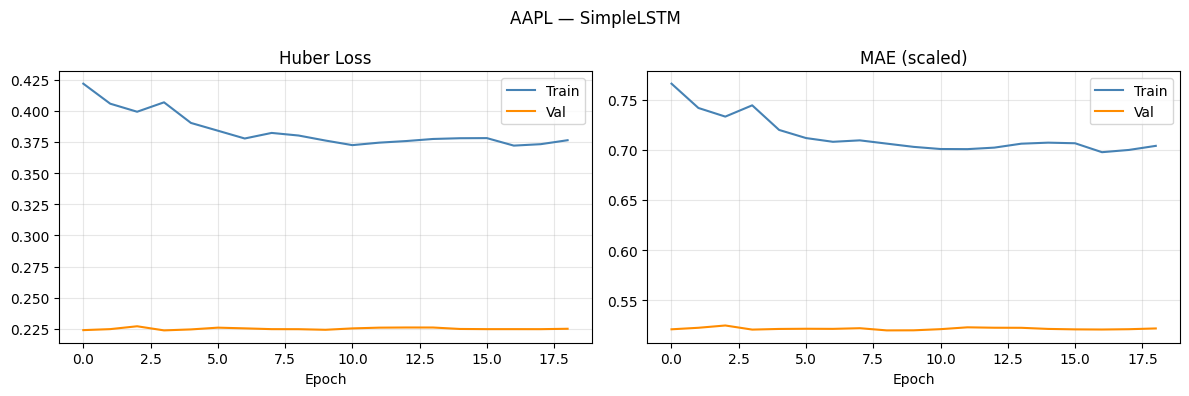

In [34]:
print('=' * 50)
print('Training: SimpleLSTM')
print('=' * 50)
tf.keras.backend.clear_session()
model_simple = build_simple_lstm(N_FEATURES, LOOKBACK)
hist_simple  = train_model(model_simple, data)
plot_history(hist_simple, DEMO_TICKER + ' — SimpleLSTM')

Training: AttentionLSTM
Epoch 1/100
54/54 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.4450 - mae: 0.7848 - val_loss: 0.2519 - val_mae: 0.5472 - learning_rate: 5.0000e-04
Epoch 2/100
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.3986 - mae: 0.7219 - val_loss: 0.2350 - val_mae: 0.5244 - learning_rate: 5.0000e-04
Epoch 3/100
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.3858 - mae: 0.7066 - val_loss: 0.2308 - val_mae: 0.5192 - learning_rate: 5.0000e-04
Epoch 4/100
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.3902 - mae: 0.7099 - val_loss: 0.2317 - val_mae: 0.5215 - learning_rate: 5.0000e-04
Epoch 5/100
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.3794 - mae: 0.6922 - val_loss: 0.2324 - val_mae: 0.5215 - learning_rate: 5.0000e-04
Epoch 6/100
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.3818 - mae: 0.6962 - val_loss: 0.2319 - val_mae: 0.5210 - learning_rate: 5.0000e-04
Epoch 7/100
48/54 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.4003 - mae: 0.7186
Epoch 7: ReduceLROnPlateau

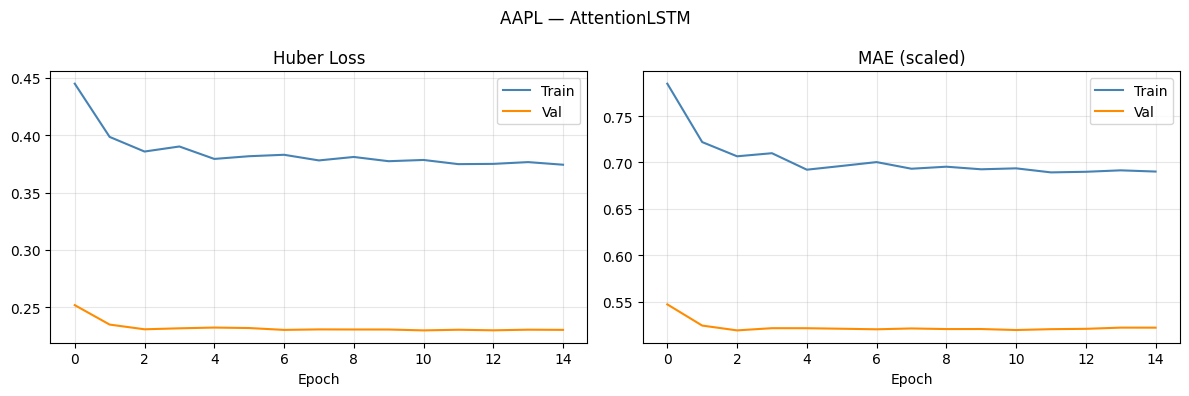

In [35]:
print('=' * 50)
print('Training: AttentionLSTM')
print('=' * 50)
tf.keras.backend.clear_session()
model_attn = build_attention_lstm(N_FEATURES, LOOKBACK)
hist_attn  = train_model(model_attn, data)
plot_history(hist_attn, DEMO_TICKER + ' — AttentionLSTM')

## 10. Evaluation & Comparison

In [36]:
def evaluate_model(model, data, split='test'):
    X      = data['X_' + split]
    y_true = data['y_' + split]
    close  = data['close_' + split]
    sy     = data['scaler_y']

    y_pred  = model.predict(X, verbose=0).flatten()
    lr_true = sy.inverse_transform(y_true.reshape(-1, 1)).flatten()
    lr_pred = sy.inverse_transform(y_pred.reshape(-1, 1)).flatten()

    p_true  = close * np.exp(lr_true)
    p_pred  = close * np.exp(lr_pred)

    mae_model = mean_absolute_error(p_true, p_pred)
    mae_naive = mean_absolute_error(p_true, close)
    mape      = float(np.mean(np.abs((p_true - p_pred) / p_true)) * 100)
    skill     = 1 - mae_model / mae_naive
    dir_acc   = direction_accuracy(y_true, y_pred, close, sy)

    return {
        'MAE':    round(mae_model, 4),
        'MAPE':   round(mape,      4),
        'Skill':  round(skill,     4),
        'DirAcc': round(dir_acc,   2),
    }


results = {
    'Ridge':         {'MAE': None, 'MAPE': None, 'Skill': None, 'DirAcc': round(ridge_test_dir, 2)},
    'SimpleLSTM':    evaluate_model(model_simple, data, 'test'),
    'AttentionLSTM': evaluate_model(model_attn,   data, 'test'),
}

header = '{:<18} {:>8} {:>8} {:>8} {:>8}'.format('Model', 'MAE', 'MAPE', 'Skill', 'DirAcc')
print()
print(DEMO_TICKER + ' — Test Set Comparison')
print(header)
print('-' * 56)
for name, m in results.items():
    mae_s   = '{:.4f}'.format(m['MAE'])   if m['MAE']   is not None else '   -  '
    mape_s  = '{:.2f}%'.format(m['MAPE']) if m['MAPE']  is not None else '   -  '
    skill_s = '{:+.3f}'.format(m['Skill']) if m['Skill'] is not None else '   -  '
    dir_s   = '{:.1f}%'.format(m['DirAcc'])
    print('{:<18} {:>8} {:>8} {:>8} {:>8}'.format(name, mae_s, mape_s, skill_s, dir_s))

print()
print('Skill > 0  -> beats naive baseline (tomorrow = today)')
print('DirAcc > 52% with positive skill -> genuine predictive value')


AAPL — Test Set Comparison
Model                   MAE     MAPE    Skill   DirAcc
--------------------------------------------------------
Ridge                   -        -        -      51.9%
SimpleLSTM           2.7863    1.20%   -0.004    51.1%
AttentionLSTM        2.8007    1.21%   -0.009    53.8%

Skill > 0  -> beats naive baseline (tomorrow = today)
DirAcc > 52% with positive skill -> genuine predictive value


## 11. Visualise Predictions

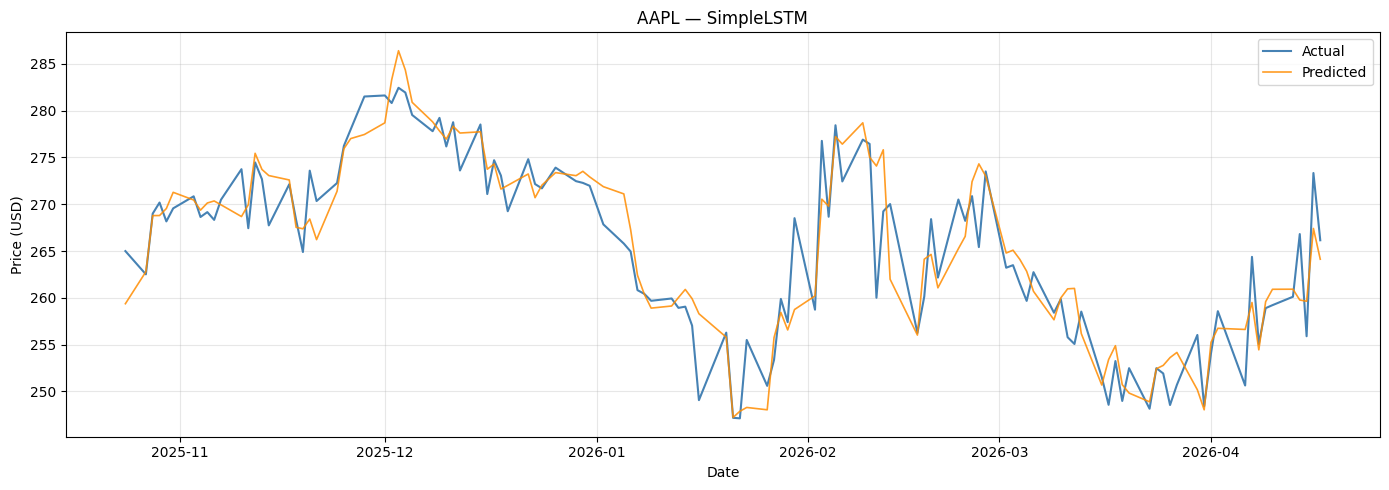

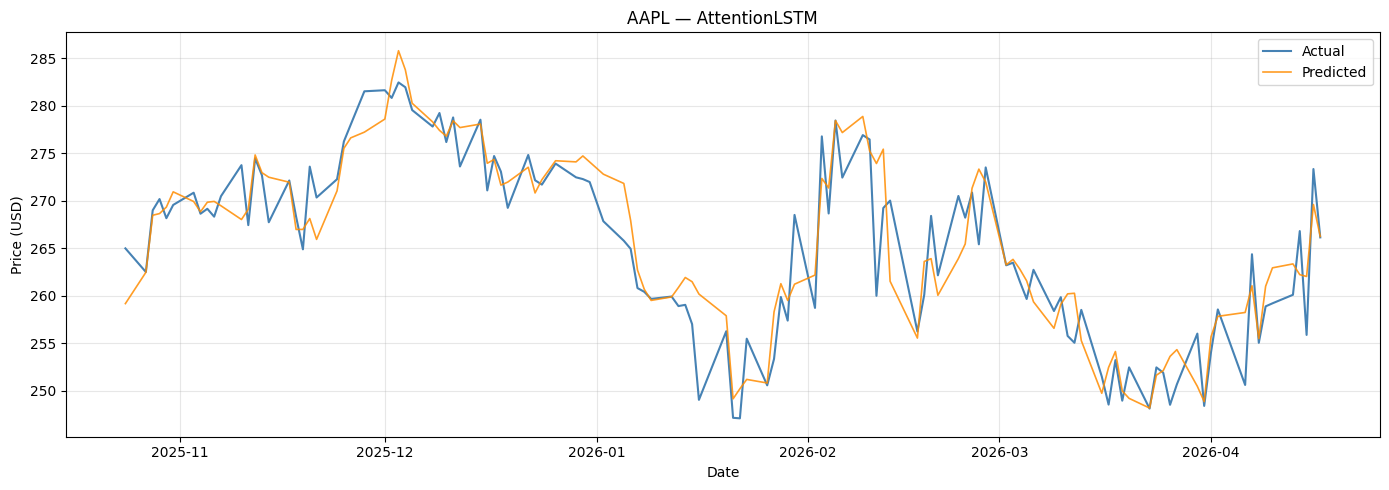

In [37]:
def plot_predictions(model, data, split='test', title='', n_days=120):
    X      = data['X_' + split][-n_days:]
    y_true = data['y_' + split][-n_days:]
    close  = data['close_' + split][-n_days:]
    dates  = data['dates_' + split][-n_days:]
    sy     = data['scaler_y']

    y_pred  = model.predict(X, verbose=0).flatten()
    lr_true = sy.inverse_transform(y_true.reshape(-1, 1)).flatten()
    lr_pred = sy.inverse_transform(y_pred.reshape(-1, 1)).flatten()

    p_true = close * np.exp(lr_true)
    p_pred = close * np.exp(lr_pred)

    fig, ax = plt.subplots(figsize=(14, 5))
    ax.plot(dates, p_true, label='Actual',    color='steelblue',  linewidth=1.5)
    ax.plot(dates, p_pred, label='Predicted', color='darkorange', linewidth=1.2, alpha=0.85)
    ax.set_title(title or DEMO_TICKER + ' — ' + split + ' predictions (last ' + str(n_days) + ' days)')
    ax.set_xlabel('Date')
    ax.set_ylabel('Price (USD)')
    ax.legend()
    ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()


plot_predictions(model_simple, data, title=DEMO_TICKER + ' — SimpleLSTM')
plot_predictions(model_attn,   data, title=DEMO_TICKER + ' — AttentionLSTM')

## 12. Key Diagnostic — Val MAE Over Epochs

**What to look for:**
- Original model: val MAE **flat from epoch 1** (persistence shortcut, learned nothing)
- Improved models: val MAE should **decrease over the first 10–30 epochs**
- Still flat → bottleneck is features, not architecture (Ridge result confirms this)

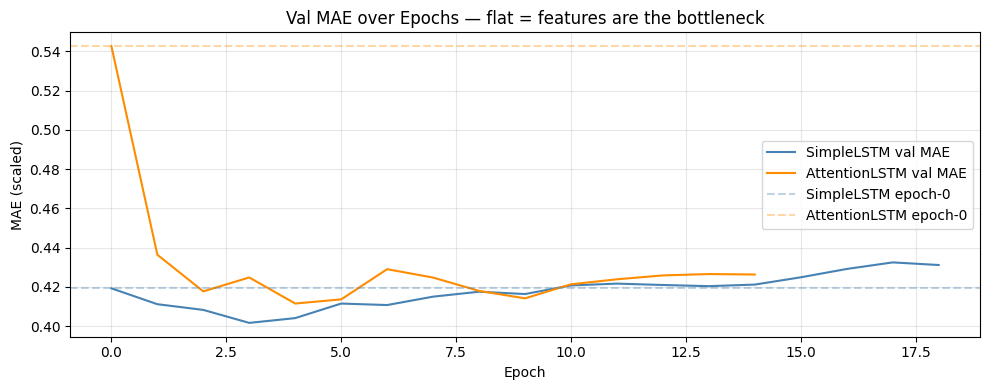

In [15]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(hist_simple.history['val_mae'], label='SimpleLSTM val MAE',    color='steelblue')
ax.plot(hist_attn.history['val_mae'],   label='AttentionLSTM val MAE', color='darkorange')
ax.axhline(hist_simple.history['val_mae'][0], color='steelblue',  linestyle='--', alpha=0.35, label='SimpleLSTM epoch-0')
ax.axhline(hist_attn.history['val_mae'][0],   color='darkorange', linestyle='--', alpha=0.35, label='AttentionLSTM epoch-0')
ax.set_title('Val MAE over Epochs — flat = features are the bottleneck')
ax.set_xlabel('Epoch')
ax.set_ylabel('MAE (scaled)')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Summary

| Model | Key change | What to look for |
|-------|-----------|-----------------|
| **Ridge** | Linear, flattened features | Diagnostic ceiling — if Ridge ≈ LSTM, only better features will help |
| **SimpleLSTM** | 32-unit, dropout=0.4 | Val MAE should decrease, not stay flat |
| **AttentionLSTM** | 64-unit + MHA + residual | Best for non-uniform temporal patterns |

If all three models converge to ~50–53% directional accuracy, the 20 single-stock technical indicators do not contain enough signal at daily frequency for large-cap NASDAQ stocks.  
The next step is **better inputs** — cross-sectional alpha, earnings calendar, options implied volatility, or news sentiment.